# 1D Non-linear Poisson-Boltzmann Benchmark

This notebook solves the **full non-linear** Poisson-Boltzmann equation in 1D.

## Model
For a symmetric electrolyte, the non-linear PB equation is:

$$
\frac{d^2 \phi}{dx^2} = \kappa^2 \sinh\!\left(\frac{z e \phi}{k_B T}\right)
$$

where $\phi$ is electric potential, $z$ is ionic valence, and $\kappa^{-1}$ is the Debye length.

## When to use this notebook
- Moderate to high surface potential
- Cases where linear PB underestimates near-wall charge screening
- Validation of solver robustness for stronger nonlinearity

> Use this notebook to capture finite-potential effects that the linear model cannot represent.

## What to check in results
- Sharper near-wall gradients than linear PB
- Larger deviation from exponential decay as potential increases

In [1]:
import unxt
import quaxed.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
from fdm_edl.edl import ElectricalDoubleLayer
from fdm_edl import _constants

In [3]:
# 0.01 M 1-1 electrolyte, T = 298 K, epsilon_r = 78.5
edl_obj = ElectricalDoubleLayer("input.json")

In [4]:
beta = 1.0 / (_constants.BOLTZMANN_CONSTANT * edl_obj.temperature).to("eV")
# print((_constants.ELEMENTARY_CHARGE * unxt.Q(0.001, "V")).to("eV") * beta)

In [5]:
def boltzmann_factor(phi, valancy: int = 1):
    return jnp.exp((-_constants.ELEMENTARY_CHARGE * phi * beta * valancy).to(""))

In [6]:
x = unxt.Quantity(jnp.linspace(0, 50.0, 500), unit="nm")
sigma = _constants.ELEMENTARY_CHARGE / unxt.Quantity(1e4, "angstrom^2")

exp_factor = jnp.exp(-(x / edl_obj.electrolyte.debye_length)).to("")
alpha = 1.0 / jnp.sqrt(
    8
    * _constants.BOLTZMANN_CONSTANT
    * edl_obj.temperature
    * edl_obj.electrolyte.epsilon
    * edl_obj.electrolyte.ions[0].molar_conc
    * _constants.AVOGADRO_NUMBER
)

In [7]:
a = (
    (jnp.sqrt((sigma * alpha).to(" ") ** 2 + 1) - 1)
    / (sigma * alpha).to(" ")
    * exp_factor
)

In [8]:
_phi = (
    unxt.Quantity(jnp.arctanh(a).value, unit=" ")
    * 4
    * (_constants.BOLTZMANN_CONSTANT * edl_obj.temperature).to("eV")
)
phi = unxt.Quantity(_phi.value, "V")

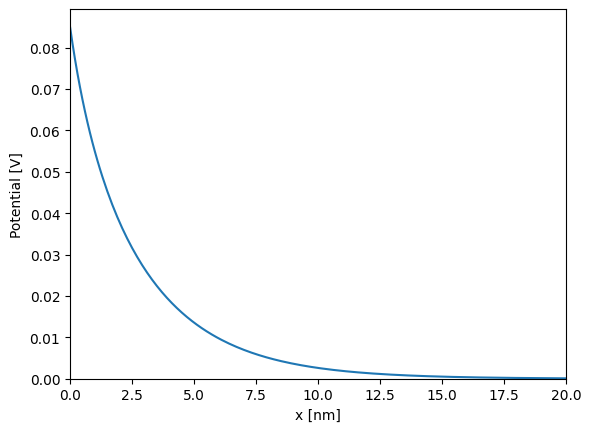

In [9]:
fig, ax = plt.subplots()

ax.plot(x.to("nm"), phi.to("V"))

ax.set_xlim(0, 20)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Potential [V]")

plt.show()

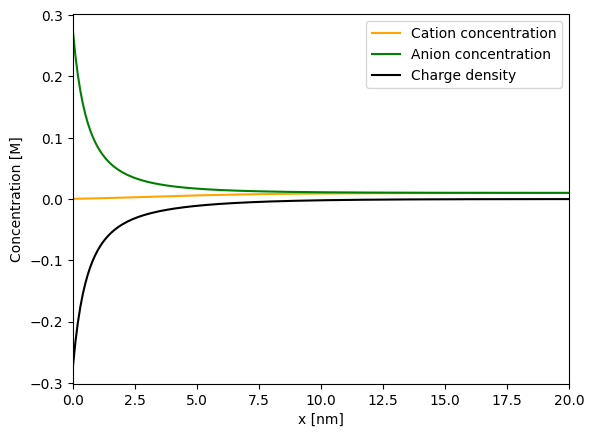

In [10]:
fig, ax = plt.subplots()

c_cation = edl_obj.electrolyte.ions[0].molar_conc * boltzmann_factor(phi, valancy=1)
c_anion = edl_obj.electrolyte.ions[1].molar_conc * boltzmann_factor(phi, valancy=-1)

ax.plot(x.to("nm"), c_cation, color="orange", label="Cation concentration")
ax.plot(x.to("nm"), c_anion, color="green", label="Anion concentration")
ax.plot(x.to("nm"), c_cation - c_anion, color="k", label="Charge density")

# ax.plot(x.to("nm"), rho, "--", color="red", label="Charge density from Poisson's equation")

ax.set_xlim(0, 20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Concentration [M]")
ax.legend()

plt.show()